Napredna analiza podataka - Projekat - Klasterizacija teksta

Detekcija Spam mejlova na osnovu sadržaja mejla

Uvod: Razraditi

Instalacija potrebnih biblioteka

In [83]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [84]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import spacy
import seaborn as sb

Prvobitno ucitavanje dataset-a sa dodatnim informacijama o broju unikatnih vrednosti opservacija i NaN  vrednosti

In [85]:
data = pd.read_csv('./data/emails/CEAS_08.csv')
data

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1
...,...,...,...,...,...,...,...
39149,CNN Alerts <charlene-detecton@btcmarketing.com>,email1007@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:34:50 -0400",CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0
39150,CNN Alerts <idgetily1971@careplusnj.org>,email104@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:35:11 -0400",CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0
39151,Abhijit Vyas <xpojhbz@gmail.com>,fxgmqwjn@triptracker.net,"Fri, 08 Aug 2008 22:00:43 +0800",Slideshow viewer,Hello there ! \nGreat work on the slide show v...,0,0
39152,Joseph Brennan <vupzesm@columbia.edu>,zqoqi@spamassassin.apache.org,"Fri, 08 Aug 2008 09:00:46 -0500",Note on 2-digit years,"\nMail from sender , coming from intuit.com\ns...",0,0


U datom datasetu postoje sledece promenljive:
Sender - Naziv posiljaoca  i mejl adresa
Receiver - mejl adresa primaoca
Date - datum slanja
Subject - naslov mejla
Body - sadrzaj mejla
Label - binarna promenljiva koja oznacava da li mejl predstavlja phishing napad ili ne. 1 je phishing dok 0 nije.
Urls - binarna promenljiva koja oznacava da li se u mejlu nalaze url-ovi

Prvo sto cu da proverim je ucestalost vrednosti promenljivih koje u sebi sadrze NA vrednosti

In [86]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [87]:
data.receiver.value_counts()

receiver
user6@gvc.ceas-challenge.cc                                                          1375
wkilxloc@opensuse.org                                                                1230
user2.1@gvc.ceas-challenge.cc                                                        1037
user2.2@gvc.ceas-challenge.cc                                                         922
user2.4@gvc.ceas-challenge.cc                                                         738
                                                                                     ... 
vegetahan@hotmail.com                                                                   1
'Squirrelmail Developers Mailing List' <aqcvnwkdyeem-hbpoa@lists.sourceforge.net>       1
Frank Steiner <lwvrlirx-chvz0@bio.ifi.lmu.de>                                           1
Olyvia Meyer <kwycqr.unjnu@gmail.com>, Samantha Gilmour <orribdffovqb@gmail.com>        1
rgkwpdahmhmail@cs.cmu.edu, faq@engr.orst.edu, ji-ivay@googlegroups.com                  1
N

Kao sto se moze videti, veliki broj mejlova ima iste primaoce, pretpostavljam da su ovi mejlovi sluzili kao honeypot-ovi za prikupljanje phishing napada. Podaci primaoca se onda tesko mogu koristiti za klasifikaciju.

Postoji rizik od overfitting-a, ukoliko treniram model na ovim podacima. Jedino za sta bi mogla da mi sluzi promenljiva primaoc je da se na primer poredi adresa primaoca i posiljaoca. Ukoliko su mejl serveri isti, onda postoji veca sansa da je mejl validan

Probacu da nadjem mejlove(opservacije) koje sadrze isti mejl servera posiljaoca i primaoca

In [88]:
sender_domain = data['sender'].str.split("@").str[1].str.removesuffix(">")
receiver_domain = data['receiver'].str.split("@").str[1].str.removesuffix(">")

internal_sending_data = data.loc[sender_domain == receiver_domain]
internal_sending_data

,sender,receiver,date,subject,body,label,urls
22,ohwwlejs-pbfotbp@list.scms.waikato.ac.nz,iuxxdkqk@list.scms.waikato.ac.nz,"Tue, 05 Aug 2008 18:32:19 -0500","Wekalist Digest, Vol 60, Issue 10",Send Wekalist mailing list submissions to\n\ti...,0,1
54,Perl Jobs <xycn-vtnhz@perl.org>,necc@perl.org,"Tue, 05 Aug 2008 02:47:22 -0800","[Perl Jobs] Perl developer, Hungary, Budapest",Online URL for this job: http://jobs.perl.org/...,0,1
55,Perl Jobs <xycn-vtnhz@perl.org>,necc@perl.org,"Tue, 05 Aug 2008 02:48:34 -0800","[Perl Jobs] Software Engineer, Weather (onsite...",Online URL for this job: http://jobs.perl.org/...,0,1
57,Perl Jobs <xycn-vtnhz@perl.org>,necc@perl.org,"Tue, 05 Aug 2008 02:47:32 -0800",[Perl Jobs] Perl & Apache & Unix/Linux & Mysql...,Online URL for this job: http://jobs.perl.org/...,0,1
59,Perl Jobs <xycn-vtnhz@perl.org>,necc@perl.org,"Tue, 05 Aug 2008 08:39:46 -0800","[Perl Jobs] Perl Developer (onsite), United St...",Online URL for this job: http://jobs.perl.org/...,0,1
...,...,...,...,...,...,...,...
38861,"""Alexander Gelbukh (MICAI-2008)"" <fwj2317t@mic...",'AI group' <aqz4438d@micai.org>,"Fri, 08 Aug 2008 05:43:21 -0600",[UAI] CFP: MICAI 2008: Artifiical Intelligence...,MICAI 2008: 7th Mexican International Conferen...,0,0
38880,ysxshwee-tyrxx-liyysxs@lists.tuxonice.net,enpsfhxz-stvnz@lists.tuxonice.net,"Fri, 08 Aug 2008 13:33:35 +0000","TuxOnIce-users Digest, Vol 37, Issue 8",Send TuxOnIce-users mailing list submissions t...,0,1
38885,ysxshwee-tyrxx-liyysxs@lists.tuxonice.net,enpsfhxz-stvnz@lists.tuxonice.net,"Fri, 08 Aug 2008 13:33:56 +0000","TuxOnIce-users Digest, Vol 37, Issue 8",Send TuxOnIce-users mailing list submissions t...,0,1
38959,Georg Brandl <splmn@python.org>,zttpnd-wnlugsli@python.org,"Fri, 08 Aug 2008 15:14:13 +0200","Pygments 0.10 ""Malzeug"" released",I've just uploaded the Pygments 0.10 packages ...,0,1


In [89]:
internal_sent = internal_sending_data.loc[internal_sending_data['label'] == 0]
print(f"Ukupan broj internih mejlova koji nisu phising: {len(internal_sent)} od {len(internal_sending_data)}")
#TODO: Kreirati promenljivu is_internal

Ukupan broj internih mejlova koji nisu phising: 1226 od 1263


In [90]:
data['is_internal'] = sender_domain == receiver_domain 
data['is_internal'] = data['is_internal'].map({True:1,False: 0})


Kao sto se moze videti veliki broj izdvojenih mejlova su zaista rezultat internog slanja. Predstavljaju oko 3% internog slanja, nije veliki broj ovakvih opservacija ali predstavljaju bitan podatak za povecanje sigurnosti bezbednog mejla. Moguce je izvrsiti transformaciju gde ce se dodati binarna promenljiva is_internal. Zakljucujem da postoji velika korelacija izmedju poklapanja serverskih domena i status spam-a

Sledece sto se moze proveriti je da li kako izgledaju opservacije koje nemaju specificiranog primaoca, ovakvi mejlovi obicno predstavljaju spam ako su mejlovi samo navedeni u bcc

In [91]:
no_recipient_mails = data.loc[data['receiver'].isna() == True]
no_recipient_mails

,sender,receiver,date,subject,body,label,urls,is_internal
294,Tony Earnshaw <uhbyq@hetnet.nl>,NaN,"Wed, 06 Aug 2008 00:47:37 +0100",Re: [dkim-milter-discuss] postfix + dkim-filte...,"Daniel Black skrev, on 08-02-2008 13:19:\n> On...",0,0,0
335,Tony Earnshaw <uhbyq@hetnet.nl>,NaN,"Wed, 06 Aug 2008 00:49:33 +0100",Re: [dkim-milter-discuss] postfix + dkim-filte...,"Wietse Venema skrev, on 08-02-2008 14:48:\n> T...",0,0,0
601,mouss <qpeqr@netoyen.net>,NaN,"Wed, 06 Aug 2008 01:04:34 +0100",Re: permission denied while using pipe in mast...,"Jordi Moles wrote:\n> Hi,\n>\n> the shellscrip...",0,0,0
611,mouss <qpeqr@netoyen.net>,NaN,"Wed, 06 Aug 2008 01:04:58 +0100",Re: Forwarding all localmail,Randy Ramsdell wrote:\n> I would like to know ...,0,0,0
620,mouss <qpeqr@netoyen.net>,NaN,"Wed, 06 Aug 2008 01:05:33 +0100",Re: SASL questions,"AlxFrag wrote:\n> Hi,\n>\n> i have a couple of...",0,0,0
...,...,...,...,...,...,...,...,...
38953,mouss <qpeqr@netoyen.net>,NaN,"Fri, 08 Aug 2008 14:41:20 +0100",Re: Challenging Local Sender/Recipient Spam,Gary C. New wrote:\n> We are having an issue w...,0,0,0
38971,mouss <qpeqr@netoyen.net>,NaN,"Fri, 08 Aug 2008 14:43:38 +0100",Re: failover for check_policy_service,"Alex wrote:\n> Hi,\n>\n> i've a question relat...",0,0,0
38975,mouss <qpeqr@netoyen.net>,NaN,"Fri, 08 Aug 2008 14:44:24 +0100",Re: Question about changing the road of authen...,"Johnny Maillist wrote:\n> Hi,\n> I want to cha...",0,0,0
38998,mouss <qpeqr@netoyen.net>,NaN,"Fri, 08 Aug 2008 14:46:11 +0100","Re: Lots of ""scam"" messages getting through SA","Robert S wrote:\n> I have started, over the la...",0,0,0


In [92]:
no_recipient_mails_ham = no_recipient_mails.loc[no_recipient_mails['label'] == 0]
print(f"Ukupan broj mejlova bez primaoca koji nisu spam: {len(no_recipient_mails_ham)} od {len(no_recipient_mails)}")

Ukupan broj mejlova bez primaoca koji nisu spam: 459 od 462


Moja pocetna tvrdnja ipak nije bila tacna, tako da cu odstraniti opservacije koje nemaju vrednost primaoca

In [93]:
data.dropna(axis=0,subset=['receiver'],inplace=True)

Sledeca promenljiva koju posmatram je date promenljiva. Treniranjem modela nad ovom promenljivom, predstavlja veliki rizik za overfitting modela i datumi su iz 2008 godine. Jedino kako mislim da bi se ova promenljiva mogla koristiti je tako da se izdvoje dani u nedelji i na nauci model u kada su napadi najcesci. Zasad to necu raditi. Proveriti sa profesorkom

Posto treniranjem modela na celokupnim datumima nece biti korisno, iz datuma cu izdvojiti dane u nedelji kao i vreme kad su se slali mejlovi pa cu utvrditi da li oni doprinose razdvajanju klasa. Pre izdvajanja, potrebno je da konvertujem object promenljivu u datetime promenljivu

In [94]:
data['date'] = pd.to_datetime(data['date'], format="%a, %d %b %Y %H:%M:%S %z",utc=True, errors='coerce')

In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38692 entries, 0 to 39153
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   sender       38692 non-null  object             
 1   receiver     38692 non-null  object             
 2   date         38677 non-null  datetime64[ns, UTC]
 3   subject      38669 non-null  object             
 4   body         38692 non-null  object             
 5   label        38692 non-null  int64              
 6   urls         38692 non-null  int64              
 7   is_internal  38692 non-null  int64              
dtypes: datetime64[ns, UTC](1), int64(3), object(4)
memory usage: 2.7+ MB


In [96]:
data['day_of_week'] = data['date'].dt.strftime("%a")

In [97]:
data['day_of_week'] = data['day_of_week'].map({'Sun':0,'Mon':1,'Tue':2,'Wed':3,'Thu':4,'Fri':5,'Sat': 5})
data['day_of_week']

0        2.0
1        2.0
2        3.0
3        2.0
4        2.0
        ... 
39149    5.0
39150    5.0
39151    5.0
39152    5.0
39153    5.0
Name: day_of_week, Length: 38692, dtype: float64

Isto cu uraditi i za casove u toku dana

In [98]:
data['hour_of_day'] = data['date'].dt.strftime("%H")

Posto sam izveo promenljive iz datetime-a za analizu, odbacicu originalnu promenljivu datetime

In [99]:
data.drop(columns=['date'], axis=1)

,sender,receiver,subject,body,label,urls,is_internal,day_of_week,hour_of_day
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,0,2.0,23
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,0,2.0,23
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,0,3.0,08
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1,0,2.0,23
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1,0,2.0,23
...,...,...,...,...,...,...,...,...,...
39149,CNN Alerts <charlene-detecton@btcmarketing.com>,email1007@gvc.ceas-challenge.cc,CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0,0,5.0,14
39150,CNN Alerts <idgetily1971@careplusnj.org>,email104@gvc.ceas-challenge.cc,CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0,0,5.0,14
39151,Abhijit Vyas <xpojhbz@gmail.com>,fxgmqwjn@triptracker.net,Slideshow viewer,Hello there ! \nGreat work on the slide show v...,0,0,0,5.0,14
39152,Joseph Brennan <vupzesm@columbia.edu>,zqoqi@spamassassin.apache.org,Note on 2-digit years,"\nMail from sender , coming from intuit.com\ns...",0,0,0,5.0,14


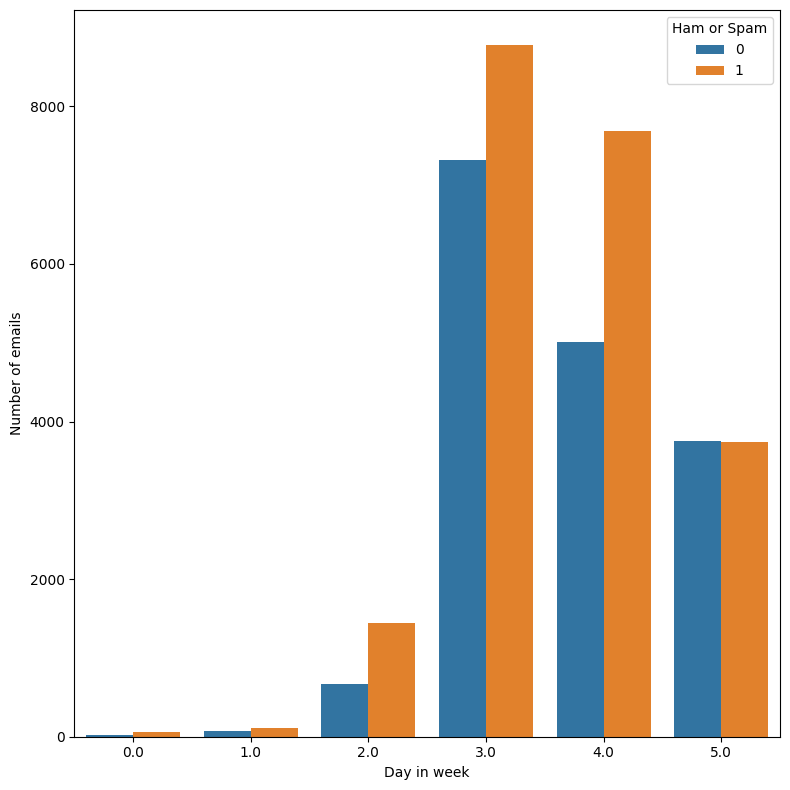

In [100]:
plt.figure(figsize=(8,8))
sb.countplot(data=data,x='day_of_week',hue='label')
plt.xlabel('Day in week')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()


Nisam siguran na osnovu grafikona da procenim da li se raspodele razlikuju, pa cu primeniti Hi-kvadrat test da utvrdim koliko je jaka veza izmedju dva kategoricka obelezja

In [101]:
from scipy.stats import chi2_contingency
crosstab = pd.crosstab(data['day_of_week'],data['label'])
stat,p,dof,expected = chi2_contingency(crosstab)
print("Ho: Promenljive dan u nedelji i label su statisticki nezavisni")
print("H1: Promenljive dan u nedelji i label su statisticki zavisni")
print(f"P vrednost Hi-kvadrat testa je: {p}")

Ho: Promenljive dan u nedelji i label su statisticki nezavisni
H1: Promenljive dan u nedelji i label su statisticki zavisni
P vrednost Hi-kvadrat testa je: 5.752293661622676e-77


Dobijena p vrednost je manja od 0.05 tako da odbacujem nultu i prihvatam alternativnu hipotezu da postoji zavisnost izmedju ove dve promenljive. Zadrzacu ovu promenljivu

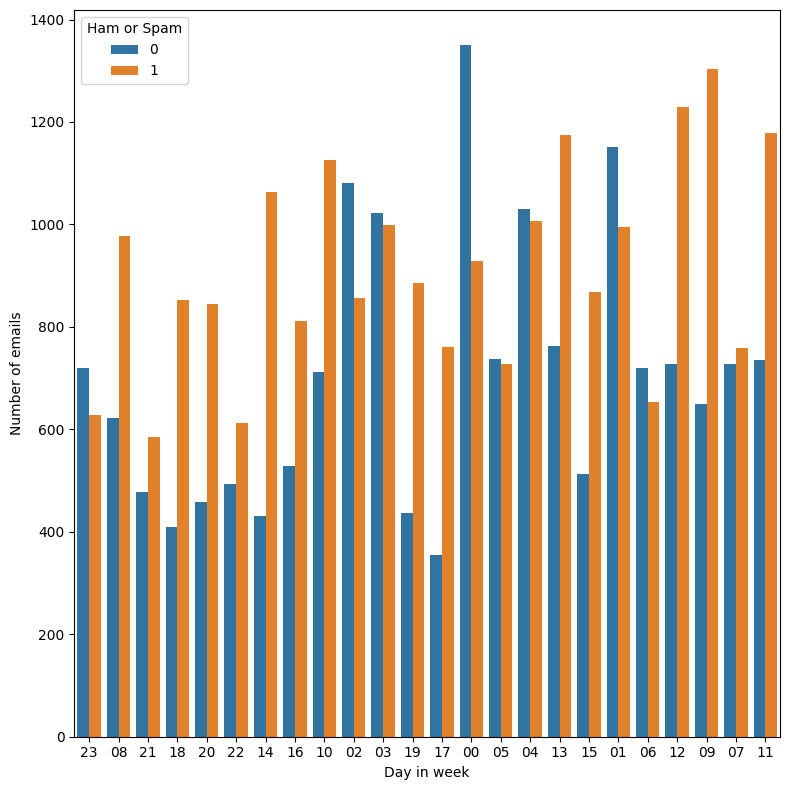

In [102]:
plt.figure(figsize=(8,8))
sb.countplot(data=data,x='hour_of_day',hue='label')
plt.xlabel('Day in week')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Sa grafikona vec mogu da vidim da se raspodele casova u odnosu na labelu raziliku. Ali za svaki slucaj cu primeniti Hi kvadrat test da ovo potvrdim

In [103]:
crosstab = pd.crosstab(data['hour_of_day'],data['label'])
stat,p,dof,expected = chi2_contingency(crosstab)
print("Ho: Promenljive dan u nedelji i label su statisticki nezavisni")
print("H1: Promenljive dan u nedelji i label su statisticki zavisni")
print(f"P vrednost Hi-kvadrat testa je: {p}")

Ho: Promenljive dan u nedelji i label su statisticki nezavisni
H1: Promenljive dan u nedelji i label su statisticki zavisni
P vrednost Hi-kvadrat testa je: 3.1158002182536813e-245


Dobijena p vrednost je manja od 0.05 tako da odbacujem nultu i prihvatam alternativnu hipotezu da postoji zavisnost izmedju ove dve promenljive. Zadrzacu ovu promenljivu

Pre nastavka analize potrebno je da proverim kako raspodela promenljive urls u odnosu na vrednost label(phising ili ne) utice na razdvajanje klasa

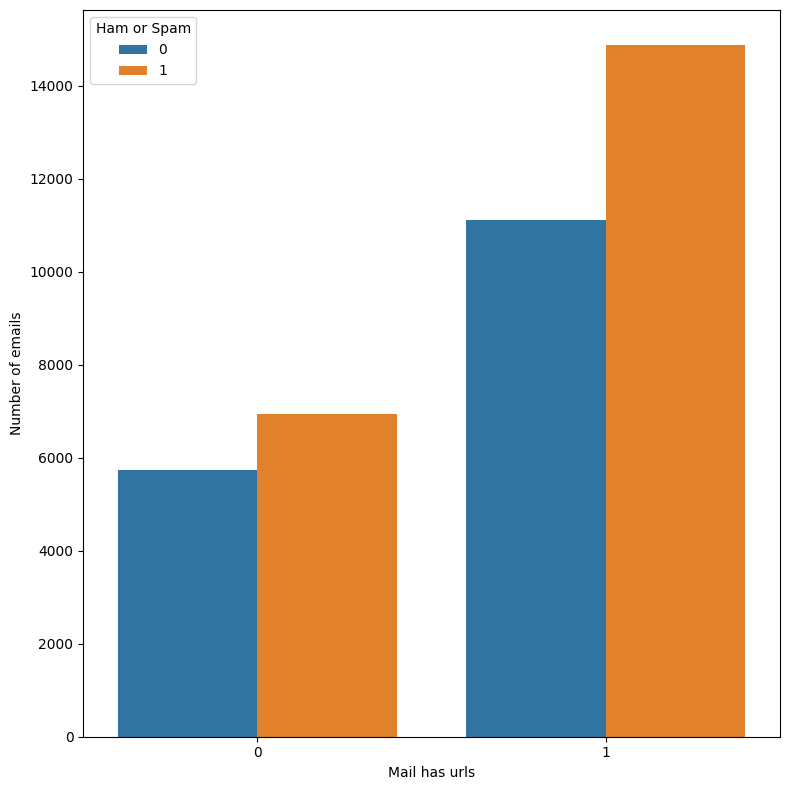

In [104]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='urls',hue='label')
plt.xlabel('Mail has urls')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()


Na osnovu ovog grafikona zakljucujem da su raspodele mejlova sa i bez url linkova iste. Tvrdim da ova promenljiva nece doprineti razdvajanju klasa

In [105]:
data = data[['sender','subject','body','day_of_week','hour_of_day','label']].copy()

In [106]:
data.label.value_counts(normalize=True)

label
1    0.564432
0    0.435568
Name: proportion, dtype: float64

Sobzirom da ne postoji veliki disbalans u izlaznoj promenljivoj, neću koristiti SMOTE metodu balansiranja

Transformacija tekstualnih promenljvih koriscenjem spacy biblioteke

Sender - provericu da li mejl server u sebi sadrzi brojeve(npr. m1crosoft.com), jer to cesto moze predstavljati kljucan indikator spam mejlova. Opet sama adresa posiljaoca nece imati koristi za treniranje modela, ali moguce je izvesti promenljivu na primer has_number_in_sender_server.

In [107]:
# Za pocetak koristicu najmanji spacy model koji ne podrzava vektorsku repreztaciju teksta, zato sto mi je prvo cilj da testiram uspesnos Bag of Words metode
import spacy
nlp_sm = spacy.load('en_core_web_sm')

In [ ]:
def domain_has_numbers(email):
    if "@" in email:
        email = email.split("@")[1].removesuffix(">")
        return any(char.isdigit() for char in email)
    return False

In [126]:
data['has_number_in_sender_server'] = data['sender'].apply(domain_has_numbers)

AttributeError: 'str' object has no attribute 'contains'

In [115]:
data

,sender,subject,body,day_of_week,hour_of_day,label,has_number_in_sender_server
0,Young Esposito <Young@iworld.de>,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",2.0,23,1,False
1,Mok <ipline's1983@icable.ph>,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,2.0,23,1,True
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,3.0,08,1,True
3,Michael Parker <ivqrnai@pobox.com>,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,2.0,23,0,False
4,Gretchen Suggs <externalsep1@loanofficertool.com>,SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,2.0,23,1,True
...,...,...,...,...,...,...,...
39149,CNN Alerts <charlene-detecton@btcmarketing.com>,CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,5.0,14,1,False
39150,CNN Alerts <idgetily1971@careplusnj.org>,CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,5.0,14,1,True
39151,Abhijit Vyas <xpojhbz@gmail.com>,Slideshow viewer,Hello there ! \nGreat work on the slide show v...,5.0,14,0,False
39152,Joseph Brennan <vupzesm@columbia.edu>,Note on 2-digit years,"\nMail from sender , coming from intuit.com\ns...",5.0,14,0,False
